Estimated glucose depletion slope: -0.2139 mM/min
Estimated glucose demand: 10.14 mmol/hr
Feed concentration: 100.0 mM
Required feed rate: 0.1014 L/hr


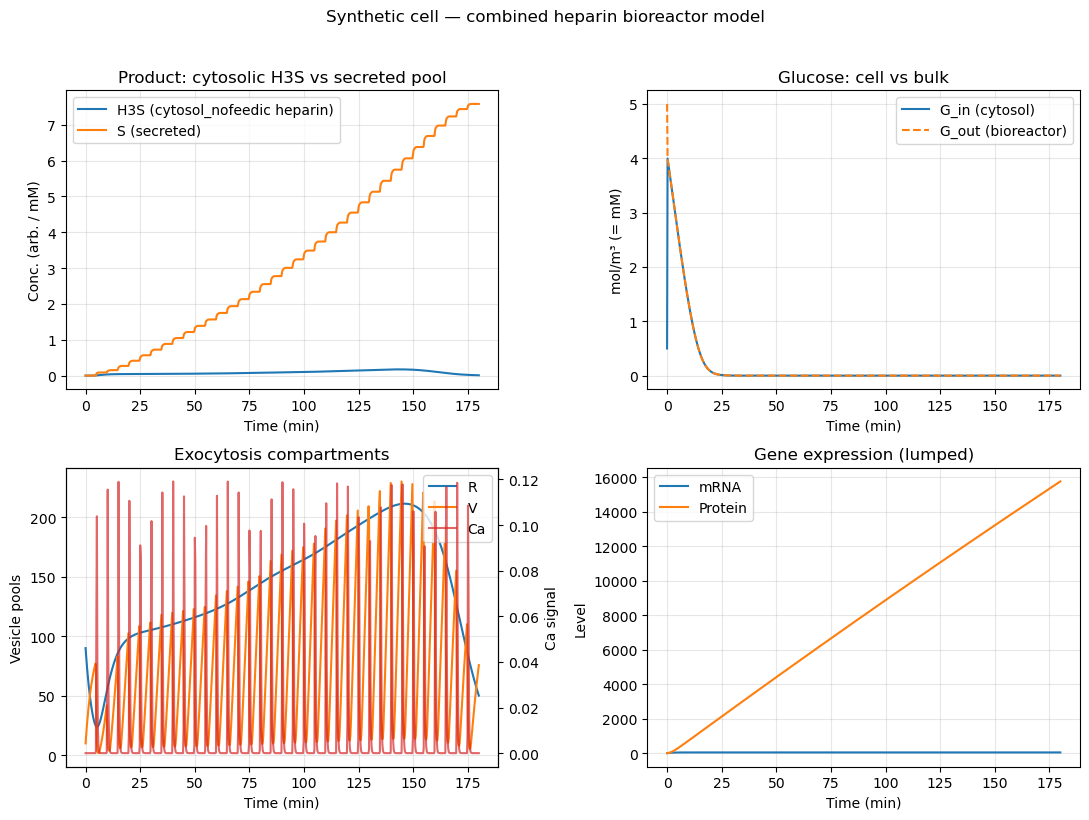

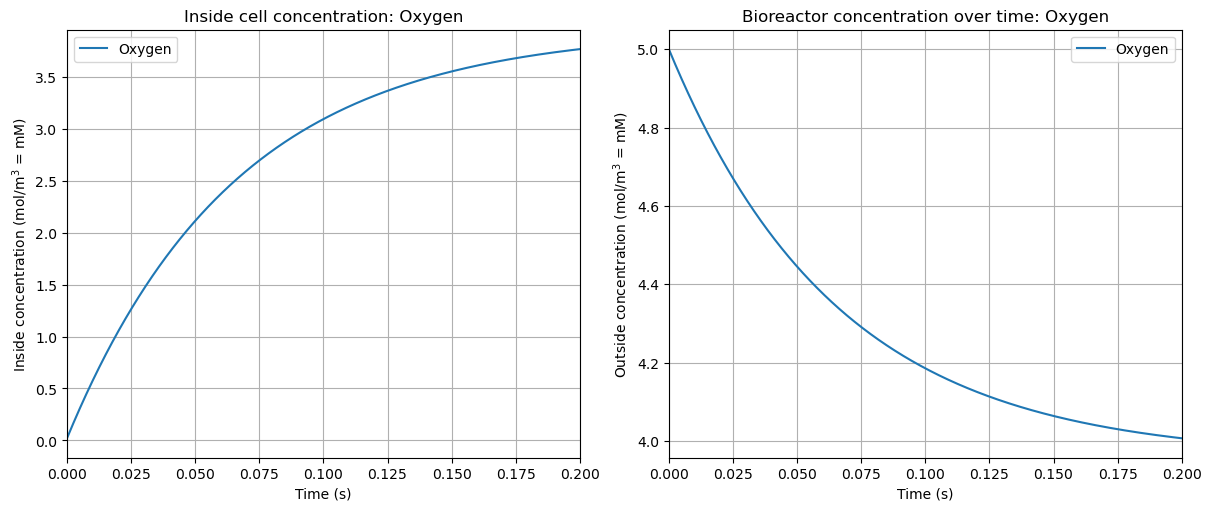

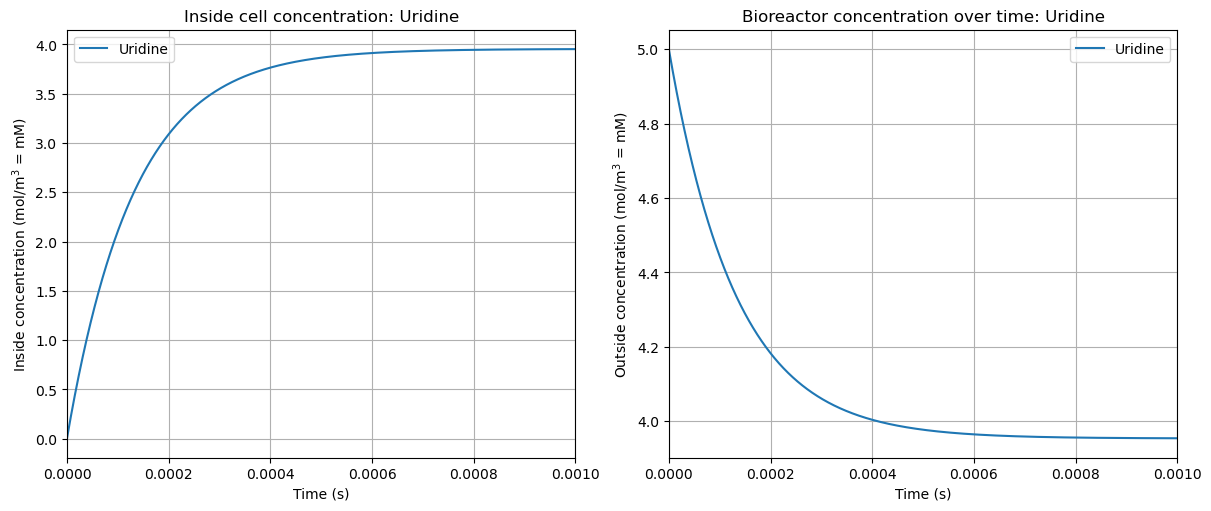

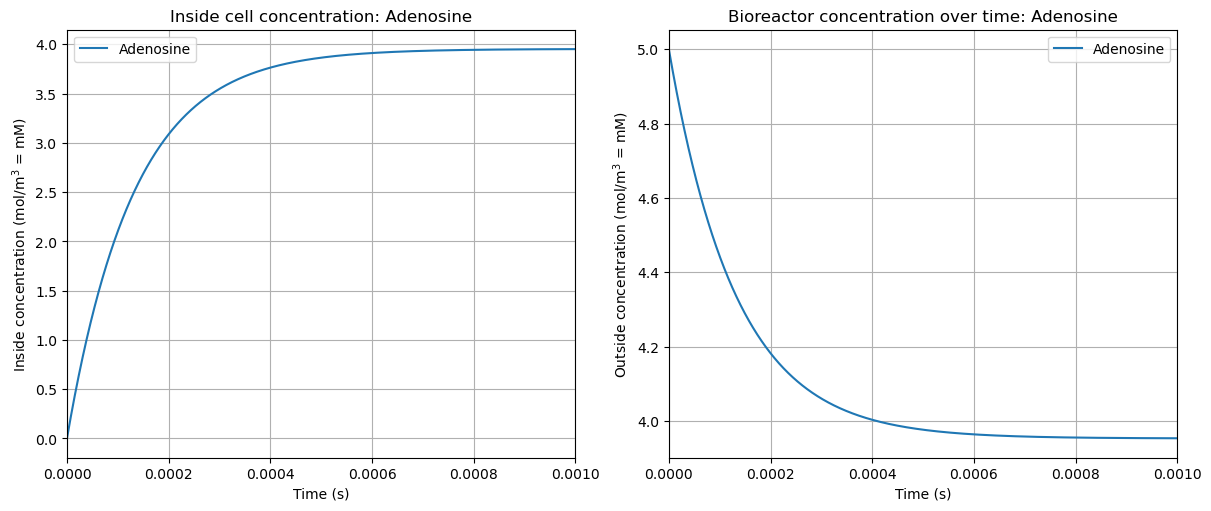

Final secreted heparin proxy S: 7.580231359990654
Final labels count: 42

Feed sweep summary
F_in (L/hr) | S_final | G_out_final | G_out_min | G_in_min
0.0000 | 7.5802 | 0.0000 | 0.0000 | 0.0000
0.0080 | 4.5018 | 0.0331 | 0.0331 | 0.0331
0.0160 | 4.4723 | 0.0685 | 0.0685 | 0.0685
0.0240 | 4.4532 | 0.1063 | 0.1063 | 0.1063
0.0320 | 4.3869 | 0.1469 | 0.1469 | 0.1469
0.0400 | 4.2839 | 0.1906 | 0.1906 | 0.1906
0.0480 | 4.2008 | 0.2376 | 0.2376 | 0.2376
0.0560 | 4.1412 | 0.2884 | 0.2884 | 0.2884
0.0640 | 4.1811 | 0.3436 | 0.3436 | 0.3436
0.0720 | 4.2129 | 0.4035 | 0.4035 | 0.4035
0.0800 | 4.2366 | 0.4690 | 0.4690 | 0.4690
0.0880 | 4.2546 | 0.5407 | 0.5407 | 0.5000
0.0960 | 4.2686 | 0.6196 | 0.6196 | 0.5000
0.1040 | 4.2799 | 0.7067 | 0.7067 | 0.5000
0.1120 | 4.2891 | 0.8034 | 0.8034 | 0.5000
0.1200 | 4.2968 | 0.9114 | 0.9114 | 0.5000


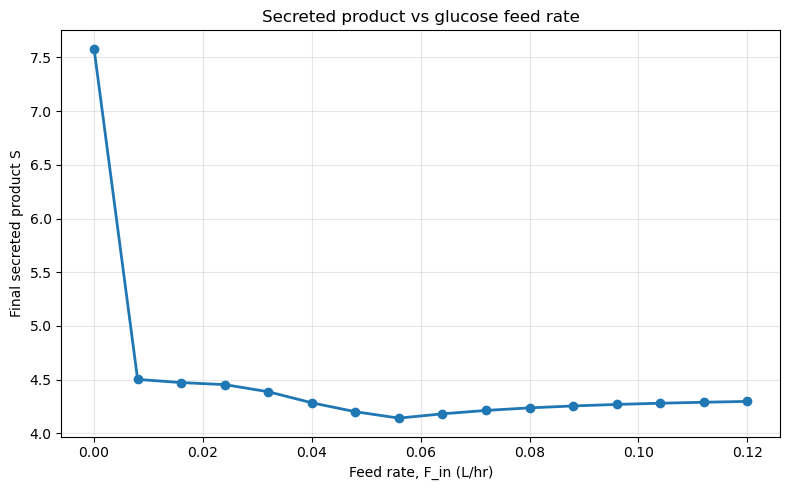

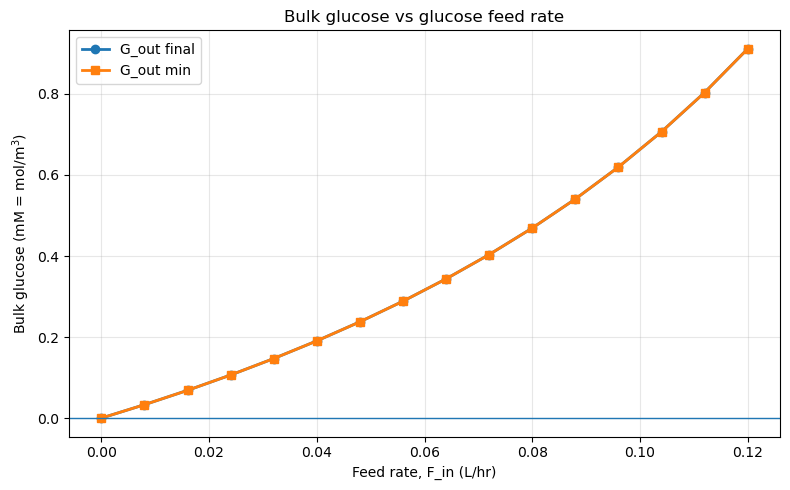

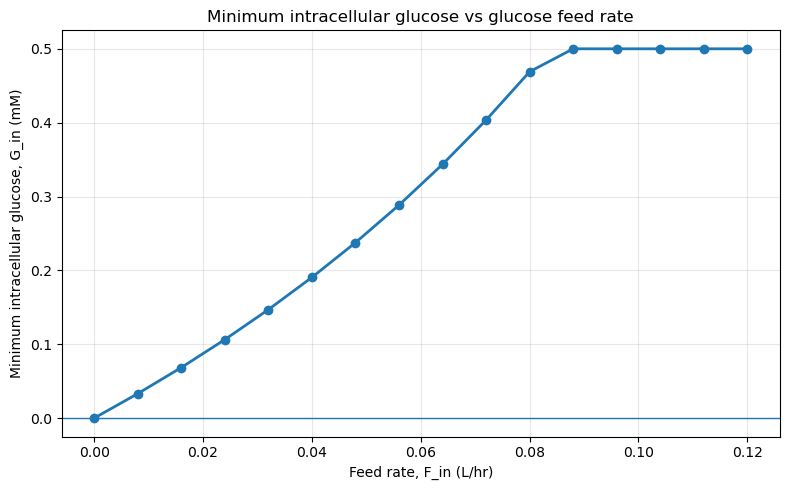

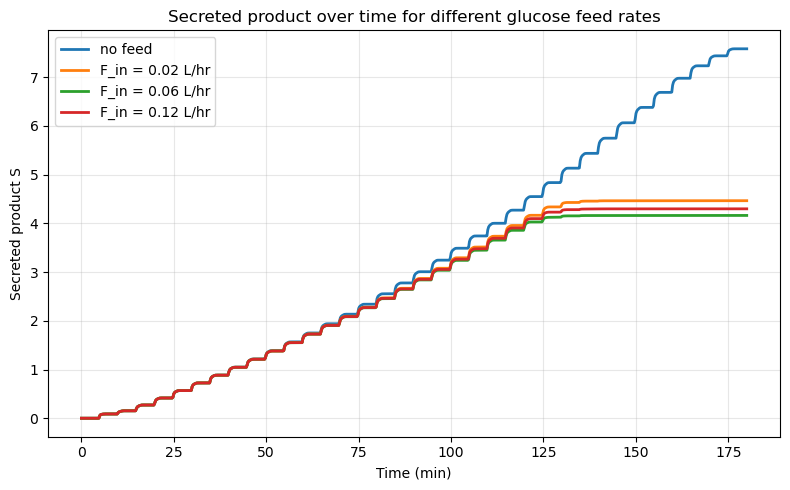

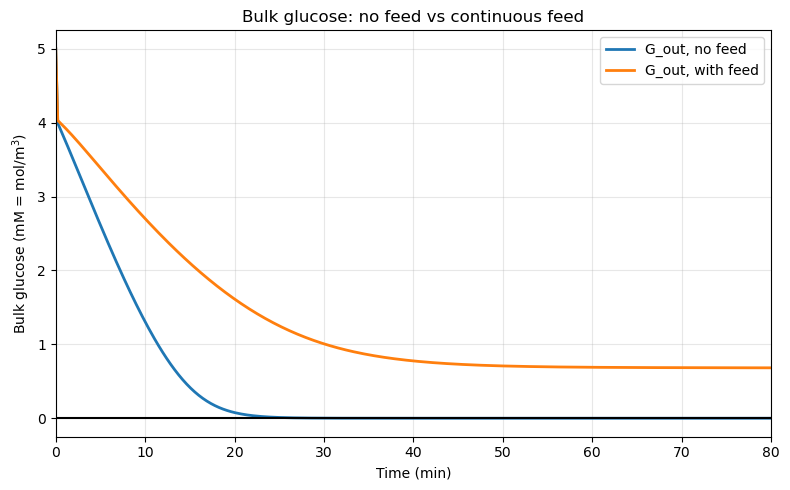

In [9]:

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


def mm_single_substrate(Vmax, S, Km):
    return Vmax * S / (Km + S + 1e-12)


def mm_two_substrate(Vmax, A, B, Km_A, Km_B):
    denom = Km_A * Km_B + Km_B * A + Km_A * B + A * B + 1e-12
    return Vmax * A * B / denom


def reversible_epimerization_forward(GlcA_chain, k_eq):
    """Quasi-equilibrium GlcA <-> IdoA (kept for API compatibility)."""
    return (k_eq * GlcA_chain) / (1.0 + k_eq)



def sulfation_ode(t, y, k):
    Hs, Hp, PAPS = y
    v = k * Hs * PAPS
    return [-v, v, -v]


def membrane_flux(D, C_out, C_in, L):
    """Fick’s first law: positive flux = into the cell."""
    return D * (C_out - C_in) / L


def diffusion_derivatives(C_in, C_out, D, area_cell, V_cell, V_out, L, n_cells):
    J = membrane_flux(D, C_out, C_in, L)
    dC_in_dt = (area_cell / V_cell) * J
    dC_out_dt = -(n_cells * area_cell / V_out) * J
    return dC_in_dt, dC_out_dt


def default_bioreactor_geometry():
    """Spherical cell + well-mixed bulk"""
    cell_radius = 10e-6  # m
    membrane_thickness = 5e-9  # m
    n_cells = 5e10
    batch_volume = 1e-3  # m³
    area = 4 * np.pi * cell_radius**2
    v_cell = (4.0 / 3.0) * np.pi * cell_radius**3
    v_cells_total = n_cells * v_cell
    v_out = batch_volume - v_cells_total
    return {
        "CELL_RADIUS": cell_radius,
        "MEMBRANE_THICKNESS": membrane_thickness,
        "NUMBER_OF_CELLS": n_cells,
        "CELL_SURFACE_AREA": area,
        "CELL_VOLUME": v_cell,
        "OUTSIDE_VOLUME": max(v_out, 1e-9),
        "D_glucose": 6.0e-5 * 1e-3,  
    }


def v_packaging(H, K, Vmax, n):
    return Vmax * H**n / (K**n + H**n)


def ca_pulse(t, pulse_times, A=1.0, sigma=0.1):
    return sum(A * np.exp(-((t - ti) ** 2) / (2 * sigma**2)) for ti in pulse_times)


def k_exo(C, K, kmax, n):
    return kmax * C**n / (K**n + C**n)


def f_hep(t, y, c, k_sulfation, pulse_times):
    """
    Standalone lumped sulfation + exocytosis.
    State: [Hs, Hp, PAPS, R, C, V, S].  c = [Kpack, Kexo, Vmax, kmax, n1, n2,
    kdeg, krel, kca, q, A, sigma].  Time in minutes.
    """
    Hs, Hp, PAPS, R, C, V, S = y
    v_sulfation = k_sulfation * Hs * PAPS
    Kpack, Kexo, Vmax, kmax, n1, n2, kdeg, krel, kca, q, A, sigma = c
    dHs_dt = -v_sulfation
    dHp_dt = v_sulfation - v_packaging(Hp, Kpack, Vmax, n1) - kdeg * Hp
    dPAPS_dt = -v_sulfation
    dR_dt = (1.0 / q) * v_packaging(Hp, Kpack, Vmax, n1) - krel * R
    dC_dt = ca_pulse(t, pulse_times, A=A, sigma=sigma) - kca * C
    dV_dt = krel * R - k_exo(C, Kexo, kmax, n2) * V
    dS_dt = q * k_exo(C, Kexo, kmax, n2) * V
    return [dHs_dt, dHp_dt, dPAPS_dt, dR_dt, dC_dt, dV_dt, dS_dt]


def heparin_pathway_ode(t, y, p):
    (
        HNAc,
        HNS,
        HEpi,
        H2S,
        H6S,
        H3S,
        PAPS,
        PAP,
        Glucose,
        G6P,
        F6P,
        G1P,
        UDP_Glc,
        UDP_GlcA,
        GlcN6P,
        GlcN1P,
        GlcNAc1P,
        UDP_GlcNAc,
        Glutamine,
        Glutamate,
        NH3,
        AcetylCoA,
        CoASH,
        UTP,
        UDP,
        UMP,
        ATP,
        ADP,
        AMP,
        PPi,
        Pi,
        APS,
        Sulfite,
        NADH,
        NAD,
    ) = y

    v_hex = mm_two_substrate(
        p["Vmax_hex"], Glucose, ATP, p["Km_Glucose_hex"], p["Km_ATP_hex"]
    )
    v_PGI_f = mm_single_substrate(p["Vmax_PGI_f"], G6P, p["Km_G6P_PGI"])
    v_PGI_r = mm_single_substrate(p["Vmax_PGI_r"], F6P, p["Km_F6P_PGI"])
    v_PGM_f = mm_single_substrate(p["Vmax_PGM_f"], G6P, p["Km_G6P_PGM"])
    v_PGM_r = mm_single_substrate(p["Vmax_PGM_r"], G1P, p["Km_G1P_PGM"])
    v_GlmS = mm_two_substrate(
        p["Vmax_GlmS"], F6P, Glutamine, p["Km_F6P_GlmS"], p["Km_Gln_GlmS"]
    )
    v_GlmM = mm_single_substrate(p["Vmax_GlmM"], GlcN6P, p["Km_GlcN6P_GlmM"])
    v_GlmU_acetyl = mm_two_substrate(
        p["Vmax_GlmU_acetyl"],
        GlcN1P,
        AcetylCoA,
        p["Km_GlcN1P_GlmU_acetyl"],
        p["Km_AcetylCoA_GlmU_acetyl"],
    )
    v_GlmU_UTP = mm_two_substrate(
        p["Vmax_GlmU_UTP"],
        GlcNAc1P,
        UTP,
        p["Km_GlcNAc1P_GlmU_UTP"],
        p["Km_UTP_GlmU_UTP"],
    )
    v_GalU = mm_two_substrate(
        p["Vmax_GalU"], G1P, UTP, p["Km_G1P_GalU"], p["Km_UTP_GalU"]
    )
    v_KfiD = mm_two_substrate(
        p["Vmax_KfiD"], UDP_Glc, NAD, p["Km_UDP_Glc_KfiD"], p["Km_NAD_KfiD"]
    )
    v_heparosan_base = mm_single_substrate(
        p["Vmax_kfiA"], UDP_GlcNAc, p["Km_kfiA"]
    )
    coupling_glca = UDP_GlcA / (p["Km_kfiC"] + UDP_GlcA + 1e-12)
    v_heparosan = v_heparosan_base * coupling_glca

    pap_inhibition = 1.0 / (1.0 + PAP / (p["Ki_PAP"] + 1e-12))
    vNS = pap_inhibition * mm_two_substrate(
        p["Vmax_NS"], HNAc, PAPS, p["Km_HNAc_NS"], p["Km_PAPS_NS"]
    )
    vEpi = mm_single_substrate(p["Vmax_Epi"], HNS, p["Km_Epi"])
    inhibitor_2ost = p.get("inhibitor_2OST", 0.0)
    Ki_2OST = p.get("Ki_2OST", np.inf)
    inhibition_2ost = 1.0 / (1.0 + inhibitor_2ost / (Ki_2OST + 1e-12))
    v2OST = pap_inhibition * inhibition_2ost * mm_two_substrate(
        p["Vmax_2OST"], HEpi, PAPS, p["Km_HEpi_2OST"], p["Km_PAPS_2OST"]
    )
    v6OST = pap_inhibition * mm_two_substrate(
        p["Vmax_6OST"], H2S, PAPS, p["Km_H2S_6OST"], p["Km_PAPS_6OST"]
    )
    inhibitor_3ost = p.get("inhibitor_3OST", 0.0)
    Ki_3OST = p.get("Ki_3OST", np.inf)
    inhibition_3ost = 1.0 / (1.0 + inhibitor_3ost / (Ki_3OST + 1e-12))
    v3OST = pap_inhibition * inhibition_3ost * mm_two_substrate(
        p["Vmax_3OST"], H6S, PAPS, p["Km_H6S_3OST"], p["Km_PAPS_3OST"]
    )

    v_gln_synth = p["k_gln_synth"] * Glutamate * NH3 * ATP
    v_acs = p["k_acs"] * p["Acetate_pool"] * CoASH * ATP
    v_ndk_f = p["k_ndk_f"] * ATP * UDP
    v_ndk_r = p["k_ndk_r"] * ADP * UTP
    v_umpk = p["k_umpk"] * UMP * ATP
    v_ppase = p["k_ppase"] * PPi
    v_ATPS = mm_two_substrate(
        p["Vmax_ATPS"], Sulfite, ATP, p["Km_Sulfite_ATPS"], p["Km_ATP_ATPS"]
    )
    v_APSK = mm_two_substrate(
        p["Vmax_APSK"], APS, ATP, p["Km_APS_APSK"], p["Km_ATP_APSK"]
    )
    v_PAPase = p["k_PAPase"] * PAP
    v_AMP_recharge = p["k_AMP_recharge"] * AMP * ATP
    v_ATP_regen = p["k_ATP_regen"] * ADP
    v_NAD_regen = p["k_NAD_regen"] * NADH

    dHNAc_dt = v_heparosan - vNS
    dHNS_dt = vNS - vEpi
    dHEpi_dt = vEpi - v2OST
    dH2S_dt = v2OST - v6OST
    dH6S_dt = v6OST - v3OST
    dH3S_dt = v3OST
    dPAPS_dt = -(vNS + v2OST + v6OST + v3OST) + v_APSK
    dPAP_dt = (vNS + v2OST + v6OST + v3OST) - v_PAPase
    dGlucose_dt = -v_hex #glucose is being consumed at the rate of the hexokinase reaction
    dG6P_dt = v_hex - v_PGI_f + v_PGI_r - v_PGM_f + v_PGM_r
    dF6P_dt = v_PGI_f - v_PGI_r - v_GlmS
    dG1P_dt = v_PGM_f - v_PGM_r - v_GalU
    dUDP_Glc_dt = v_GalU - v_KfiD
    dUDP_GlcA_dt = v_KfiD - v_heparosan
    dGlcN6P_dt = v_GlmS - v_GlmM
    dGlcN1P_dt = v_GlmM - v_GlmU_acetyl
    dGlcNAc1P_dt = v_GlmU_acetyl - v_GlmU_UTP
    dUDP_GlcNAc_dt = v_GlmU_UTP - v_heparosan
    dGlutamine_dt = -v_GlmS + v_gln_synth
    dGlutamate_dt = v_GlmS - v_gln_synth
    dNH3_dt = -v_gln_synth
    dAcetylCoA_dt = -v_GlmU_acetyl + v_acs
    dCoASH_dt = v_GlmU_acetyl - v_acs
    dUTP_dt = -v_GalU - v_GlmU_UTP + v_ndk_f - v_ndk_r
    dUDP_dt = -v_ndk_f + v_ndk_r + v_umpk
    dUMP_dt = -v_umpk
    dATP_dt = (
        -v_hex
        - v_gln_synth
        - v_acs
        - v_ndk_f
        + v_ndk_r
        - v_umpk
        - v_ATPS
        - v_APSK
        - v_AMP_recharge
        + v_ATP_regen
    )
    dADP_dt = (
        v_hex
        + v_gln_synth
        + v_ndk_f
        - v_ndk_r
        + v_umpk
        + v_APSK
        + 2.0 * v_AMP_recharge
        - v_ATP_regen
    )
    dAMP_dt = v_acs + v_PAPase - v_AMP_recharge
    dPPi_dt = v_GalU + v_GlmU_UTP + v_acs + v_ATPS - v_ppase
    dPi_dt = 2.0 * v_ppase + v_gln_synth + v_PAPase
    dAPS_dt = v_ATPS - v_APSK
    dSulfite_dt = -v_ATPS
    dNADH_dt = 2.0 * v_KfiD - v_NAD_regen
    dNAD_dt = -2.0 * v_KfiD + v_NAD_regen

    return [
        dHNAc_dt,
        dHNS_dt,
        dHEpi_dt,
        dH2S_dt,
        dH6S_dt,
        dH3S_dt,
        dPAPS_dt,
        dPAP_dt,
        dGlucose_dt,
        dG6P_dt,
        dF6P_dt,
        dG1P_dt,
        dUDP_Glc_dt,
        dUDP_GlcA_dt,
        dGlcN6P_dt,
        dGlcN1P_dt,
        dGlcNAc1P_dt,
        dUDP_GlcNAc_dt,
        dGlutamine_dt,
        dGlutamate_dt,
        dNH3_dt,
        dAcetylCoA_dt,
        dCoASH_dt,
        dUTP_dt,
        dUDP_dt,
        dUMP_dt,
        dATP_dt,
        dADP_dt,
        dAMP_dt,
        dPPi_dt,
        dPi_dt,
        dAPS_dt,
        dSulfite_dt,
        dNADH_dt,
        dNAD_dt,
    ]



def gene_expression_ode(_t, m, P, k_R, gamma_R, k_P, gamma_P):
    dm = k_R - gamma_R * m
    dP = k_P * m - gamma_P * P
    return dm, dP

PATHWAY_N = 35
IDX_R, IDX_C, IDX_V, IDX_S = 35, 36, 37, 38
IDX_G_OUT, IDX_M, IDX_P = 39, 40, 41


def combined_synthetic_cell_ode(t, y, p, pulse_times, geo, exo, gene, scale, feed=None):
    """
      * Cytosolic mature heparin = H3S (y[5]). Packaging removes H3S; secreted
        pool S accumulates as in the exocytosis notebook.
      * Glucose uptake from medium: y[39] is G_out; y[8] is G_in (mol/m³ ≡ mM).
        Influx converts s⁻¹ to min⁻¹ with factor 60.
    """
    """
    feed options:
        None  -> no feed
            "F_in_L_per_hr"     volumetric feed rate [L/hr]
            "G_feed_mM"         glucose concentration in feed [mM = mol/m^3]
    """
    pathway_y = np.array(y[:PATHWAY_N], dtype=float)
    R, C, V, S = y[IDX_R], y[IDX_C], y[IDX_V], y[IDX_S]
    G_out = y[IDX_G_OUT]
    m, P = y[IDX_M], y[IDX_P]

    p_eff = dict(p)
    if scale is not None and scale.get("enabled", False):
        f_enz = scale["beta0"] + scale["beta1"] * P / (P + scale["K_P"] + 1e-12)
        for key in scale.get("keys", ("Vmax_kfiA", "Vmax_NS", "Vmax_hex")):
            if key in p_eff:
                p_eff[key] = p[key] * f_enz

    d_path = heparin_pathway_ode(t, pathway_y, p_eff)
    H3S = pathway_y[5]

    Kpack = exo["Kpack"]
    Kexo = exo["Kexo"]
    Vmax_pack = exo["Vmax_pack"]
    kmax = exo["kmax"]
    n1 = exo["n1"]
    n2 = exo["n2"]
    kdeg = exo["kdeg"]
    krel = exo["krel"]
    kca = exo["kca"]
    q = exo["q"]
    A_pulse = exo["A"]
    sigma_pulse = exo["sigma"]

    v_pack = v_packaging(H3S, Kpack, Vmax_pack, n1)
    v_exo = k_exo(C, Kexo, kmax, n2)

    d_path[5] += -v_pack - kdeg * H3S
    dR = (1.0 / q) * v_pack - krel * R
    dC = ca_pulse(t, pulse_times, A=A_pulse, sigma=sigma_pulse) - kca * C
    dV = krel * R - v_exo * V
    dS = q * v_exo * V

    G_in = pathway_y[8]
    D = geo["D_glucose"]
    L = geo["MEMBRANE_THICKNESS"]
    A = geo["CELL_SURFACE_AREA"]
    V_cell = geo["CELL_VOLUME"]
    # V_out = geo["OUTSIDE_VOLUME"]
    V_out_m3 = geo["OUTSIDE_VOLUME"]
    n_cells = geo["NUMBER_OF_CELLS"]

    J = membrane_flux(D, G_out, G_in, L)
    dG_in_from_diff = 60.0 * (A / V_cell) * J
    # dG_out = 60.0 * (-(n_cells * A / V_out) * J)
    #d_path[8] = dGlucose_dt
    dG_in_from_diff = 60.0 * (A / V_cell) * J
    dG_out_diff = 60.0 * (-(n_cells * A / V_out_m3) * J)
    d_path[8] += dG_in_from_diff #adds glucose that has diffused in to the inside glucose concentration that is retrieved with d_path[8]

    # Continuous feed, always assuming constant reactor volume:
    # dG_out/dt contribution = (F/V) * (G_feed - G_out)
    dG_out_feed = 0.0
    if feed is not None:
        F_in_L_per_hr = feed.get("F_in_L_per_hr", 0.0)
        G_feed_mM = feed.get("G_feed_mM", 0.0)

        V_out_L = V_out_m3 * 1000.0
        F_in_L_per_min = F_in_L_per_hr / 60.0
        dG_out_feed = (F_in_L_per_min / V_out_L) * (G_feed_mM - G_out)

    dG_out = dG_out_diff + dG_out_feed

    dm, dP = gene_expression_ode(
        t, m, P, gene["k_R"], gene["gamma_R"], gene["k_P"], gene["gamma_P"]
    )

    out = d_path + [dR, dC, dV, dS, dG_out, dm, dP]
    return out


def default_pathway_params():
    return {
        "Vmax_kfiA": 1.0,
        "Km_kfiA": 0.5,
        "Vmax_NS": 1.2,
        "Km_HNAc_NS": 0.8,
        "Km_PAPS_NS": 0.5,
        "Vmax_Epi": 0.9,
        "Km_Epi": 0.6,
        "Vmax_2OST": 0.8,
        "Km_HEpi_2OST": 0.7,
        "Km_PAPS_2OST": 0.5,
        "Vmax_6OST": 0.7,
        "Km_H2S_6OST": 0.7,
        "Km_PAPS_6OST": 0.5,
        "Vmax_3OST": 0.4,
        "Km_H6S_3OST": 0.6,
        "Km_PAPS_3OST": 0.5,
        "inhibitor_2OST": 0.0,
        "Ki_2OST": np.inf,
        "inhibitor_3OST": 0.0,
        "Ki_3OST": np.inf,
        "Ki_PAP": 1.0,
        "Km_kfiC": 0.5,
        "Vmax_hex": 2.0,
        "Km_Glucose_hex": 1.0,
        "Km_ATP_hex": 0.5,
        "Vmax_PGI_f": 2.0,
        "Km_G6P_PGI": 0.5,
        "Vmax_PGI_r": 1.5,
        "Km_F6P_PGI": 0.5,
        "Vmax_PGM_f": 1.5,
        "Km_G6P_PGM": 0.5,
        "Vmax_PGM_r": 1.0,
        "Km_G1P_PGM": 0.5,
        "Vmax_GlmS": 1.2,
        "Km_F6P_GlmS": 0.5,
        "Km_Gln_GlmS": 0.5,
        "Vmax_GlmM": 1.0,
        "Km_GlcN6P_GlmM": 0.5,
        "Vmax_GlmU_acetyl": 1.0,
        "Km_GlcN1P_GlmU_acetyl": 0.5,
        "Km_AcetylCoA_GlmU_acetyl": 0.5,
        "Vmax_GlmU_UTP": 1.0,
        "Km_GlcNAc1P_GlmU_UTP": 0.5,
        "Km_UTP_GlmU_UTP": 0.5,
        "Vmax_GalU": 1.0,
        "Km_G1P_GalU": 0.5,
        "Km_UTP_GalU": 0.5,
        "Vmax_KfiD": 0.8,
        "Km_UDP_Glc_KfiD": 0.5,
        "Km_NAD_KfiD": 0.5,
        "k_gln_synth": 0.01,
        "k_acs": 0.01,
        "Acetate_pool": 10.0,
        "k_ndk_f": 0.01,
        "k_ndk_r": 0.005,
        "k_umpk": 0.01,
        "k_ppase": 0.05,
        "Vmax_ATPS": 0.8,
        "Km_Sulfite_ATPS": 0.5,
        "Km_ATP_ATPS": 0.5,
        "Vmax_APSK": 0.8,
        "Km_APS_APSK": 0.5,
        "Km_ATP_APSK": 0.5,
        "k_PAPase": 0.05,
        "k_AMP_recharge": 0.005,
        "k_ATP_regen": 0.3,
        "k_NAD_regen": 0.2,
    }


def default_initial_state(geo):
    pathway0 = [ #35 starting values for heparin_pathway_ode
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        20.0,
        0.0,
        0.5,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        10.0,
        5.0,
        10.0,
        10.0,
        5.0,
        15.0,
        5.0,
        5.0,
        40.0,
        10.0,
        2.0,
        0.0,
        10.0,
        5.0,
        10.0,
        5.0,
        20.0,
    ]
    R0, C0, V0, S0 = 90.0, 0.0, 10.0, 0.0 #exocytosis initial states
    #Initial concentrations of molecules (mol/m^3)
    G_out_0 = 5.0
    m0, P0 = 0.0, 0.0
    return pathway0 + [R0, C0, V0, S0, G_out_0, m0, P0]


def run_standalone_diffusion_demo():
    """Forward-Euler loop for O₂ / uridine / adenosine."""
    geo = default_bioreactor_geometry()
    DT = 1e-7
    
    #Initial concentrations of molecules (mol/m^3)
    #   Oxygen
    OXYGEN_C_IN_0 = 0.02
    OXYGEN_C_OUT_0 = 5.0

    #   Uridine
    URIDINE_C_IN_0 = 0.005
    URIDINE_C_OUT_0 = 5.0

    #   Adenosine 
    ADENOSINE_C_IN_0 = 0.002
    ADENOSINE_C_OUT_0 = 5.0
    
    MOLECULES = {
        "Oxygen": {
            "DiffusionCoefficient": 2.0e-13, #m^2/s 
            "C_in_0": OXYGEN_C_IN_0,
            "C_out_0": OXYGEN_C_OUT_0,
            "T_END": 2e-1 # length of modeling diffusion to set time scale for simulating (sec)
        },
        "Uridine": {
            "DiffusionCoefficient": 1e-10,
            "C_in_0": URIDINE_C_IN_0,
            "C_out_0": URIDINE_C_OUT_0,
            "T_END": 1e-3 # length of modeling diffusion to set time scale for simulating (sec)
        },
        "Adenosine": {
            "DiffusionCoefficient": 1e-10,
            "C_in_0": ADENOSINE_C_IN_0,
            "C_out_0": ADENOSINE_C_OUT_0,
            "T_END": 1e-3 # length of modeling diffusion to set time scale for simulating (sec)
        },
    }
    results = {}
    for name, data in MOLECULES.items():
        n_steps = int(data["T_END"] / DT) + 1
        t = np.linspace(0, data["T_END"], n_steps)
        C_in = np.zeros(n_steps)
        C_out = np.zeros(n_steps)
        C_in[0] = data["C_in_0"]
        C_out[0] = data["C_out_0"]
        for i in range(1, n_steps):
            d_in, d_out = diffusion_derivatives(
                C_in[i - 1],
                C_out[i - 1],
                data["DiffusionCoefficient"],
                geo["CELL_SURFACE_AREA"],
                geo["CELL_VOLUME"],
                geo["OUTSIDE_VOLUME"],
                geo["MEMBRANE_THICKNESS"],
                geo["NUMBER_OF_CELLS"],
            )
            C_in[i] = C_in[i - 1] + DT * d_in
            C_out[i] = C_out[i - 1] + DT * d_out
        results[name] = (t, C_in, C_out)
    return results, MOLECULES


def main():
    geo = default_bioreactor_geometry()
    params = default_pathway_params()
    exo = {
        "Kpack": 0.1,
        "Kexo": 0.001,
        "Vmax_pack": 0.1,
        "kmax": 5.0,
        "n1": 1,
        "n2": 2,
        "kdeg": 0.05,
        "krel": 0.3,
        "kca": 5.0,
        "q": 1e-3,
        "A": 1.0,
        "sigma": 0.1,
    }
    gene = {
        "k_R": 20.0,
        "gamma_R": 0.49,
        "k_P": 2.28,
        "gamma_P": 0.00057,
    }
    scale = {
        "enabled": True,
        "beta0": 0.85,
        "beta1": 0.15,
        "K_P": 100.0,
        "keys": ("Vmax_kfiA", "Vmax_hex", "Vmax_NS"),
    }

    t_end = 180
    pulse_every = 5.0
    pulse_times = np.arange(5.0, t_end, pulse_every)

    y0 = default_initial_state(geo)
    
    def estimate_glucose_consumption_rate(sol, geo, t_window_min=(0.0, 20.0)):
        """
        Estimate bulk glucose depletion rate from the no-feed simulation.
        Returns mmol/hr based on glucose loss from the outside compartment.
        """
        t = sol.t
        G_out = sol.y[IDX_G_OUT]

        mask = (t >= t_window_min[0]) & (t <= t_window_min[1])
        t_fit = t[mask]
        G_fit = G_out[mask]

        if len(t_fit) < 2:
            raise ValueError("Not enough points in selected time window.")

        slope_mM_per_min = np.polyfit(t_fit, G_fit, 1)[0]

        V_out_L = geo["OUTSIDE_VOLUME"] * 1000.0
        mmol_per_hr = -slope_mM_per_min * V_out_L * 60.0
        return mmol_per_hr, slope_mM_per_min


    def required_feed_rate_L_per_hr(glucose_demand_mmol_per_hr, G_feed_mM):
        """
        Since mM = mmol/L:
            F [L/hr] = demand [mmol/hr] / feed concentration [mmol/L]
        """
        if G_feed_mM <= 0:
            raise ValueError("G_feed_mM must be > 0.")
        return glucose_demand_mmol_per_hr / G_feed_mM
    
    #Simulation without input stream
    
    def fun_nofeed(t, y):
        return combined_synthetic_cell_ode(
            t, y, params, pulse_times, geo, exo, gene, scale, feed=None
        )

    t_eval = np.linspace(0.0, t_end, 800)
    sol_nofeed = solve_ivp(
        fun_nofeed,
        (0.0, t_end),
        y0,
        t_eval=t_eval,
        method="LSODA",
        atol=1e-8,
        rtol=1e-6,
    )

    if not sol_nofeed.success:
        print(sol_nofeed.message)
        return

    glucose_demand_mmol_per_hr, slope_mM_per_min = estimate_glucose_consumption_rate(
        sol_nofeed, geo, t_window_min=(0.0, 20.0)
    )

    print(f"Estimated glucose depletion slope: {slope_mM_per_min:.4f} mM/min")
    print(f"Estimated glucose demand: {glucose_demand_mmol_per_hr:.2f} mmol/hr")

    # Pick feed concentration and compute required feed rate
    G_feed_mM = 100.0
    F_in_L_per_hr = required_feed_rate_L_per_hr(glucose_demand_mmol_per_hr, G_feed_mM)

    print(f"Feed concentration: {G_feed_mM:.1f} mM")
    print(f"Required feed rate: {F_in_L_per_hr:.4f} L/hr")

    feed = {
        "F_in_L_per_hr": F_in_L_per_hr,
        "G_feed_mM": G_feed_mM,
    }

    #SIMULATION WITH FEED
    
    def fun_feed(t, y):
        return combined_synthetic_cell_ode(
            t, y, params, pulse_times, geo, exo, gene, scale, feed=feed
        )
        
    def run_feed_sweep(feed_rates_L_per_hr, G_feed_mM, t_eval):
        rows = []

        for F_in in feed_rates_L_per_hr:
            feed_i = {
                "F_in_L_per_hr": F_in,
                "G_feed_mM": G_feed_mM,
            }

            def fun_i(t, y):
                return combined_synthetic_cell_ode(
                    t, y, params, pulse_times, geo, exo, gene, scale, feed=feed_i
                )

            sol_i = solve_ivp(
                fun_i,
                (0.0, t_end),
                y0,
                t_eval=t_eval,
                method="LSODA",
                atol=1e-8,
                rtol=1e-6,
            )

            if not sol_i.success:
                print(f"Feed sweep failed at F_in = {F_in:.4f} L/hr")
                continue

            G_out_i = sol_i.y[IDX_G_OUT]
            G_in_i = sol_i.y[8]
            S_i = sol_i.y[IDX_S]

            rows.append({
                "F_in_L_per_hr": F_in,
                "S_final": float(S_i[-1]),
                "S_max": float(np.max(S_i)),
                "G_out_final": float(G_out_i[-1]),
                "G_out_min": float(np.min(G_out_i)),
                "G_out_mean": float(np.mean(G_out_i)),
                "G_in_final": float(G_in_i[-1]),
                "G_in_min": float(np.min(G_in_i)),
                "G_in_mean": float(np.mean(G_in_i)),
            })

        return rows

    sol_feed = solve_ivp(
        fun_feed,
        (0.0, t_end),
        y0,
        t_eval=t_eval,
        method="LSODA",
        atol=1e-8,
        rtol=1e-6,
    )

    if not sol_feed.success:
        print(sol_feed.message)
        return

    labels_path = [ 
        "HNAc",
        "HNS",
        "HEpi",
        "H2S",
        "H6S",
        "H3S",
        "PAPS",
        "PAP",
        "Glucose",
        "G6P",
        "F6P",
        "G1P",
        "UDP_Glc",
        "UDP_GlcA",
        "GlcN6P",
        "GlcN1P",
        "GlcNAc1P",
        "UDP_GlcNAc",
        "Glutamine",
        "Glutamate",
        "NH3",
        "AcetylCoA",
        "CoASH",
        "UTP",
        "UDP",
        "UMP",
        "ATP",
        "ADP",
        "AMP",
        "PPi",
        "Pi",
        "APS",
        "Sulfite",
        "NADH",
        "NAD",
    ]
    labels_all = labels_path + [
        "R_reserve",
        "Ca",
        "V_release",
        "S_secreted",
        "G_out",
        "mRNA",
        "Protein",
    ]

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    ax = axes[0, 0]
    for idx, name in [(5, "H3S (cytosol_nofeedic heparin)"), (38, "S (secreted)")]:
        ax.plot(sol_nofeed.t, sol_nofeed.y[idx], label=name)
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Conc. (arb. / mM)")
    ax.set_title("Product: cytosolic H3S vs secreted pool")
    ax.legend()
    ax.grid(True, alpha=0.3)

    #Plotting glucose concentrations over time
    # y[39] = glucose outside and y[8] glucose inside

    ax = axes[0, 1]
    ax.plot(sol_nofeed.t, sol_nofeed.y[8], label="G_in (cytosol)")
    ax.plot(sol_nofeed.t, sol_nofeed.y[39], label="G_out (bioreactor)", linestyle="--")
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("mol/m³ (= mM)")
    ax.set_title("Glucose: cell vs bulk")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ax.plot(sol_nofeed.t, sol_nofeed.y[35], label="R")
    ax.plot(sol_nofeed.t, sol_nofeed.y[37], label="V")
    ax2 = ax.twinx()
    ax2.plot(sol_nofeed.t, sol_nofeed.y[36], color="C3", alpha=0.7, label="Ca")
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Vesicle pools")
    ax2.set_ylabel("Ca signal")
    ax.set_title("Exocytosis compartments")
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [ln.get_label() for ln in lines], loc="upper right")
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.plot(sol_nofeed.t, sol_nofeed.y[40], label="mRNA")
    ax.plot(sol_nofeed.t, sol_nofeed.y[41], label="Protein")
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Level")
    ax.set_title("Gene expression (lumped)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle("Synthetic cell — combined heparin bioreactor model", y=1.02)
    plt.tight_layout()
    plt.show()


    #Diffusion graphs for Oxygen, Uridine, and Adenosine
    
    results, MOLECULES = run_standalone_diffusion_demo()
    for molecule_name, (t, Cin, Cout) in results.items():
        x_max = MOLECULES[molecule_name]["T_END"]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

        # Inside concentration
        ax1.plot(t, Cin, label=molecule_name)
        ax1.set_xlim(0, x_max)
        ax1.set_xlabel("Time (s)")
        ax1.set_ylabel("Inside concentration (mol/m$^3$ = mM)")
        ax1.set_title(f"Inside cell concentration: {molecule_name}")
        ax1.legend()
        ax1.grid(True)
        
        # Outside concentration
        ax2.plot(t, Cout, label=molecule_name)
        ax2.set_xlim(0, x_max)
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("Outside concentration (mol/m$^3$ = mM)")
        ax2.set_title(f"Bioreactor concentration over time: {molecule_name}")
        ax2.legend()
        ax2.grid(True)

        plt.show()
    

    print("Final secreted heparin proxy S:", float(sol_nofeed.y[38, -1]))
    print("Final labels count:", len(labels_all))
    
   
    #Optimizing input streams and secretions
   
    feed_rates = np.linspace(0.0, 0.12, 16)   # adjust range if needed
    sweep_rows = run_feed_sweep(feed_rates, G_feed_mM=100.0, t_eval=t_eval)

    if len(sweep_rows) > 0:
        F_vals = np.array([row["F_in_L_per_hr"] for row in sweep_rows])
        S_final_vals = np.array([row["S_final"] for row in sweep_rows])
        G_out_final_vals = np.array([row["G_out_final"] for row in sweep_rows])
        G_out_min_vals = np.array([row["G_out_min"] for row in sweep_rows])
        G_in_min_vals = np.array([row["G_in_min"] for row in sweep_rows])

        # Print a quick table
        print("\nFeed sweep summary")
        print("F_in (L/hr) | S_final | G_out_final | G_out_min | G_in_min")
        for row in sweep_rows:
            print(
                f"{row['F_in_L_per_hr']:.4f} | "
                f"{row['S_final']:.4f} | "
                f"{row['G_out_final']:.4f} | "
                f"{row['G_out_min']:.4f} | "
                f"{row['G_in_min']:.4f}"
            )

        # Plot 1: final secreted product vs feed rate
        plt.figure(figsize=(8, 5))
        plt.plot(F_vals, S_final_vals, marker="o", linewidth=2)
        plt.xlabel("Feed rate, F_in (L/hr)")
        plt.ylabel("Final secreted product S")
        plt.title("Secreted product vs glucose feed rate")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Plot 2: final bulk glucose vs feed rate
        plt.figure(figsize=(8, 5))
        plt.plot(F_vals, G_out_final_vals, marker="o", linewidth=2, label="G_out final")
        plt.plot(F_vals, G_out_min_vals, marker="s", linewidth=2, label="G_out min")
        plt.xlabel("Feed rate, F_in (L/hr)")
        plt.ylabel("Bulk glucose (mM = mol/m$^3$)")
        plt.title("Bulk glucose vs glucose feed rate")
        plt.axhline(0, linewidth=1)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Plot 3: minimum intracellular glucose vs feed rate
        plt.figure(figsize=(8, 5))
        plt.plot(F_vals, G_in_min_vals, marker="o", linewidth=2)
        plt.xlabel("Feed rate, F_in (L/hr)")
        plt.ylabel("Minimum intracellular glucose, G_in (mM)")
        plt.title("Minimum intracellular glucose vs glucose feed rate")
        plt.axhline(0, linewidth=1)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(8, 5))

        feed_list = [0.0, 0.02, 0.06, 0.12]   # choose a few representative feed rates

        for F_in in feed_list:
            feed_i = None if F_in == 0.0 else {
                "F_in_L_per_hr": F_in,
                "G_feed_mM": 100.0,
            }

            def fun_i(t, y):
                return combined_synthetic_cell_ode(
                    t, y, params, pulse_times, geo, exo, gene, scale, feed=feed_i
                )

            sol_i = solve_ivp(
                fun_i,
                (0.0, t_end),
                y0,
                t_eval=t_eval,
                method="LSODA",
                atol=1e-8,
                rtol=1e-6,
            )

            if sol_i.success:
                label = "no feed" if F_in == 0.0 else f"F_in = {F_in:.2f} L/hr"
                plt.plot(sol_i.t, sol_i.y[IDX_S], label=label, linewidth=2)

    plt.xlabel("Time (min)")
    plt.ylabel("Secreted product S")
    plt.title("Secreted product over time for different glucose feed rates")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    #Plot to compare glucose with feed and without feed
    plt.figure(figsize=(8, 5))
    plt.plot(sol_nofeed.t, sol_nofeed.y[IDX_G_OUT], label="G_out, no feed", linewidth=2)
    plt.plot(sol_feed.t, sol_feed.y[IDX_G_OUT], label="G_out, with feed", linewidth=2)
    plt.xlabel("Time (min)")
    plt.xlim(0,80)
    plt.ylabel("Bulk glucose (mM = mol/m$^3$)")
    plt.title("Bulk glucose: no feed vs continuous feed")
    plt.axhline(0, color='black')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    



    


if __name__ == "__main__":
    main()
